# Analiza logów - notebook prezentacyjny
Notebook pokazuje pipeline: raw logs -> parser -> AnalysisConfig -> argparse -> analyze_log_file() -> AnalysisResult -> statistics -> visualization -> OpenMP -> MPI -> CUDA (future).


## 0) Importy i ustawienia


In [1]:
from datetime import datetime
from pathlib import Path
import subprocess
import sys
import json
import pandas as pd

from IPython.display import Image, Markdown, display

from config import DEFAULT_INPUT_LOG, DEFAULT_LEVELS, DEFAULT_PHRASES, REPORTS_DIR
from domain.models import AnalysisConfig
from processing.analyzer import analyze_log_file
from processing.statistics import total_parsed_ratio, total_matched_ratio, top_error_hours
from processing.top_words import top_words
from report import result_to_dict, save_report_json, save_filtered_lines_csv
from parallel.cuda.benchmark import benchmark_cuda
from visualization.plots import (
    plot_errors_per_hour,
    plot_parallel_comparison,
    plot_level_counts,
    plot_level_filter_comparison,
    plot_top_words,
    plot_cpu_gpu_comparison,
)


In [2]:
INPUT_LOG = str(DEFAULT_INPUT_LOG)
REPORTS = Path("reports")
PLOTS = REPORTS / "plots"
REPORTS.mkdir(parents=True, exist_ok=True)
PLOTS.mkdir(parents=True, exist_ok=True)
INPUT_LOG


'C:\\Users\\PC\\PycharmProjects\\prir_projekt\\data\\raw\\Hadoop_200k.log'

## 1) Parsing i pipeline
Wejście surowe logi -> parser (`analyze_log_file`) -> `AnalysisResult`.


In [3]:
config_preview = AnalysisConfig.from_iterables(
    phrases=DEFAULT_PHRASES,
    levels=DEFAULT_LEVELS,
)
result_preview = analyze_log_file(INPUT_LOG, config_preview)
report_preview = result_to_dict(result_preview)
report_preview["summary"]


{'total_lines': 200000,
 'parsed_lines': 200000,
 'parse_errors': 0,
 'matched_lines': 200000}

In [4]:
print("Przykładowe linie dopasowane przez aktualny filtr (pierwsze 5):")
for line in result_preview.filtered_lines[:5]:
    print(line)


Przykładowe linie dopasowane przez aktualny filtr (pierwsze 5):
2015-10-01 00:00:21,000 ERROR [main] Speculator: INFO user login successful
2015-10-01 00:02:17,000 INFO [main] JobHistoryUtils: Heartbeat received
2015-10-01 00:02:21,000 INFO [main] JobHistoryUtils: ERROR failed to allocate container
2015-10-01 00:02:49,000 INFO [main] AsyncDispatcher: WARNING memory usage high
2015-10-01 00:03:25,000 INFO [main] AsyncDispatcher: FATAL application crashed


In [5]:
date_min = None
date_max = None
if result_preview.filtered_lines:
    # tylko podgląd tekstowy; zakres dat kontrolujemy przez CLI
    pass
{"pipeline": "raw logs -> AnalysisConfig -> analyze_log_file -> AnalysisResult"}


{'pipeline': 'raw logs -> AnalysisConfig -> analyze_log_file -> AnalysisResult'}

## 2) Konfiguracja analizy (AnalysisConfig)
Domyślnie analizowane są wszystkie logi (`phrases=()`, `levels=()`). Argumenty opcjonalne: `phrases`, `levels`, `date_from`, `date_to`, `error_type`, `limit`.


In [6]:
config = AnalysisConfig.from_iterables(
    phrases=DEFAULT_PHRASES,
    levels=DEFAULT_LEVELS,
)
config


AnalysisConfig(phrases=(), levels=(), error_type='ERROR', limit=None, date_from=None, date_to=None)

## 3) Główna analiza
Opis: `analyze_log_file(file_path, config)`


In [7]:
result = analyze_log_file(INPUT_LOG, config)
report = result_to_dict(result)
report["summary"]


{'total_lines': 200000,
 'parsed_lines': 200000,
 'parse_errors': 0,
 'matched_lines': 200000}

## 4) Phrase analysis przez CLI (`--phrase`)


In [8]:
commands = [
    [sys.executable, "main.py", "--input", INPUT_LOG, "--phrase", "ERROR", "--limit", "10"],
    [sys.executable, "main.py", "--input", INPUT_LOG, "--phrase", "WARNING", "--limit", "10"],
    [sys.executable, "main.py", "--input", INPUT_LOG, "--phrase", "INFO", "--limit", "10"],
]
for cmd in commands:
    print("\n$", " ".join(cmd))
    completed = subprocess.run(cmd, capture_output=True, text=True)
    print(completed.stdout[:2500])
    if completed.returncode != 0:
        print(completed.stderr)
        raise RuntimeError("CLI phrase command failed")



$ C:\Users\PC\AppData\Local\Programs\Python\Python313\python.exe main.py --input C:\Users\PC\PycharmProjects\prir_projekt\data\raw\Hadoop_200k.log --phrase ERROR --limit 10

=== SUMMARY ===
Total lines: 200000
Parsed lines: 200000
Parse errors: 0

=== PHRASE COUNTS ===
ERROR: 49904

=== LEVEL COUNTS (ALL DETECTED) ===
ERROR: 23910
FATAL: 5893
INFO: 140105
WARN: 30092

=== ERRORS PER HOUR ===
2015-10-01 00:00 -> 7
2015-10-01 01:00 -> 7
2015-10-01 02:00 -> 5
2015-10-01 03:00 -> 8
2015-10-01 04:00 -> 10
2015-10-01 05:00 -> 4
2015-10-01 06:00 -> 9
2015-10-01 07:00 -> 7
2015-10-01 08:00 -> 3
2015-10-01 09:00 -> 6

=== FILTERED LINES (first 10) ===
2015-10-01 00:02:21,000 INFO [main] JobHistoryUtils: ERROR failed to allocate container
2015-10-01 00:07:29,000 FATAL [main] AsyncDispatcher: ERROR failed to allocate container
2015-10-01 00:08:48,000 INFO [main] ContainerAllocator: ERROR failed to allocate container
2015-10-01 00:10:37,000 WARN [main] ContainerAllocator: ERROR connection timeout

## 5) Wyodrębnianie wierszy spełniających kryteria
Przykłady: tylko poziom `ERROR`, tylko zakres dat.


In [9]:
cmd = [
    sys.executable, "main.py",
    "--input", INPUT_LOG,
    "--filter-level", "ERROR",
    "--show-level-counts",
    "--limit", "10",
]
print("$", " ".join(cmd))
completed = subprocess.run(cmd, capture_output=True, text=True)
print(completed.stdout[:3000])
if completed.returncode != 0:
    print(completed.stderr)
    raise RuntimeError("CLI filter-level command failed")


$ C:\Users\PC\AppData\Local\Programs\Python\Python313\python.exe main.py --input C:\Users\PC\PycharmProjects\prir_projekt\data\raw\Hadoop_200k.log --filter-level ERROR --show-level-counts --limit 10

=== SUMMARY ===
Total lines: 200000
Parsed lines: 200000
Parse errors: 0

=== PHRASE COUNTS ===

=== LEVEL COUNTS (ALL DETECTED) ===
ERROR: 23910
FATAL: 5893
INFO: 140105
WARN: 30092

=== ERRORS PER HOUR ===
2015-10-01 00:00 -> 7
2015-10-01 01:00 -> 7
2015-10-01 02:00 -> 5
2015-10-01 03:00 -> 8
2015-10-01 04:00 -> 10
2015-10-01 05:00 -> 4
2015-10-01 06:00 -> 9
2015-10-01 07:00 -> 7
2015-10-01 08:00 -> 3
2015-10-01 09:00 -> 6

=== FILTERED LINES (first 10) ===
2015-10-01 00:00:21,000 ERROR [main] Speculator: INFO user login successful
2015-10-01 00:19:49,000 ERROR [main] JobHistoryUtils: Registering dispatcher
2015-10-01 00:24:49,000 ERROR [main] AsyncDispatcher: Container allocation successful
2015-10-01 00:28:58,000 ERROR [main] Speculator: ERROR failed to allocate container
2015-10-01 00

In [10]:
cmd = [
    sys.executable, "main.py",
    "--input", INPUT_LOG,
    "--start-date", "2015-10-18",
    "--end-date", "2023-12-31",
    "--show-level-counts",
    "--limit", "10",
]
print("$", " ".join(cmd))
completed = subprocess.run(cmd, capture_output=True, text=True)
print(completed.stdout[:3000])
if completed.returncode != 0:
    print(completed.stderr)
    raise RuntimeError("CLI date-range command failed")


$ C:\Users\PC\AppData\Local\Programs\Python\Python313\python.exe main.py --input C:\Users\PC\PycharmProjects\prir_projekt\data\raw\Hadoop_200k.log --start-date 2015-10-18 --end-date 2023-12-31 --show-level-counts --limit 10

=== SUMMARY ===
Total lines: 200000
Parsed lines: 200000
Parse errors: 0

=== PHRASE COUNTS ===

=== LEVEL COUNTS (ALL DETECTED) ===
ERROR: 23910
FATAL: 5893
INFO: 140105
WARN: 30092

=== ERRORS PER HOUR ===
2015-10-01 00:00 -> 7
2015-10-01 01:00 -> 7
2015-10-01 02:00 -> 5
2015-10-01 03:00 -> 8
2015-10-01 04:00 -> 10
2015-10-01 05:00 -> 4
2015-10-01 06:00 -> 9
2015-10-01 07:00 -> 7
2015-10-01 08:00 -> 3
2015-10-01 09:00 -> 6

=== FILTERED LINES (first 10) ===
2015-10-18 00:01:31,000 INFO [main] ContainerAllocator: Container allocation successful
2015-10-18 00:03:14,000 ERROR [main] ContainerAllocator: Heartbeat received
2015-10-18 00:04:42,000 FATAL [main] ContainerAllocator: Task execution started
2015-10-18 00:04:51,000 INFO [main] Speculator: ERROR connection ti

### 5.2) Eksport wyodrębnionych wierszy


In [11]:
filtered_csv = REPORTS / "filtered_error_lines.csv"
cmd = [
    sys.executable, "main.py",
    "--input", INPUT_LOG,
    "--filter-level", "ERROR",
    "--output-filtered-csv", str(filtered_csv),
]
print("$", " ".join(cmd))
completed = subprocess.run(cmd, capture_output=True, text=True)
print(completed.stdout[:2000])
if completed.returncode != 0:
    print(completed.stderr)
    raise RuntimeError("CLI filtered csv export failed")
filtered_csv


$ C:\Users\PC\AppData\Local\Programs\Python\Python313\python.exe main.py --input C:\Users\PC\PycharmProjects\prir_projekt\data\raw\Hadoop_200k.log --filter-level ERROR --output-filtered-csv reports\filtered_error_lines.csv

=== SUMMARY ===
Total lines: 200000
Parsed lines: 200000
Parse errors: 0

=== PHRASE COUNTS ===

=== LEVEL COUNTS (ALL DETECTED) ===
ERROR: 23910
FATAL: 5893
INFO: 140105
WARN: 30092

=== ERRORS PER HOUR ===
2015-10-01 00:00 -> 7
2015-10-01 01:00 -> 7
2015-10-01 02:00 -> 5
2015-10-01 03:00 -> 8
2015-10-01 04:00 -> 10
2015-10-01 05:00 -> 4
2015-10-01 06:00 -> 9
2015-10-01 07:00 -> 7
2015-10-01 08:00 -> 3
2015-10-01 09:00 -> 6
2015-10-01 10:00 -> 8
2015-10-01 11:00 -> 7
2015-10-01 12:00 -> 10
2015-10-01 13:00 -> 9
2015-10-01 14:00 -> 6
2015-10-01 15:00 -> 11
2015-10-01 16:00 -> 9
2015-10-01 17:00 -> 5
2015-10-01 18:00 -> 10
2015-10-01 19:00 -> 11
2015-10-01 20:00 -> 8
2015-10-01 21:00 -> 10
2015-10-01 22:00 -> 7
2015-10-01 23:00 -> 7
2015-10-02 00:00 -> 5
2015-10-02 0

WindowsPath('reports/filtered_error_lines.csv')

In [12]:
print("Wyodrębnione wiersze są zapisane w:", filtered_csv)


Wyodrębnione wiersze są zapisane w: reports\filtered_error_lines.csv


### 5.3) Filtrowanie po frazie przez CLI


In [13]:
cmd = [sys.executable, "main.py", "--input", INPUT_LOG, "--phrase", "ERROR", "--limit", "10"]
print("$", " ".join(cmd))
completed = subprocess.run(cmd, capture_output=True, text=True)
print(completed.stdout[:2500])
if completed.returncode != 0:
    print(completed.stderr)
    raise RuntimeError("CLI phrase filter command failed")


$ C:\Users\PC\AppData\Local\Programs\Python\Python313\python.exe main.py --input C:\Users\PC\PycharmProjects\prir_projekt\data\raw\Hadoop_200k.log --phrase ERROR --limit 10

=== SUMMARY ===
Total lines: 200000
Parsed lines: 200000
Parse errors: 0

=== PHRASE COUNTS ===
ERROR: 49904

=== LEVEL COUNTS (ALL DETECTED) ===
ERROR: 23910
FATAL: 5893
INFO: 140105
WARN: 30092

=== ERRORS PER HOUR ===
2015-10-01 00:00 -> 7
2015-10-01 01:00 -> 7
2015-10-01 02:00 -> 5
2015-10-01 03:00 -> 8
2015-10-01 04:00 -> 10
2015-10-01 05:00 -> 4
2015-10-01 06:00 -> 9
2015-10-01 07:00 -> 7
2015-10-01 08:00 -> 3
2015-10-01 09:00 -> 6

=== FILTERED LINES (first 10) ===
2015-10-01 00:02:21,000 INFO [main] JobHistoryUtils: ERROR failed to allocate container
2015-10-01 00:07:29,000 FATAL [main] AsyncDispatcher: ERROR failed to allocate container
2015-10-01 00:08:48,000 INFO [main] ContainerAllocator: ERROR failed to allocate container
2015-10-01 00:10:37,000 WARN [main] ContainerAllocator: ERROR connection timeout


## 6) Statystyki zdarzeń w czasie
Przykład: liczba zdarzeń na godzinę (`--show-errors-per-hour`, `--error-type`, `--top-error-hours`, `--limit`).


In [14]:
cmd = [
    sys.executable, "main.py",
    "--input", INPUT_LOG,
    "--show-errors-per-hour",
    "--error-type", "ERROR",
    "--top-error-hours", "10",
    "--limit", "10",
]
print("$", " ".join(cmd))
completed = subprocess.run(cmd, capture_output=True, text=True)
print(completed.stdout[:3000])
if completed.returncode != 0:
    print(completed.stderr)
    raise RuntimeError("CLI errors-per-hour command failed")


$ C:\Users\PC\AppData\Local\Programs\Python\Python313\python.exe main.py --input C:\Users\PC\PycharmProjects\prir_projekt\data\raw\Hadoop_200k.log --show-errors-per-hour --error-type ERROR --top-error-hours 10 --limit 10

=== SUMMARY ===
Total lines: 200000
Parsed lines: 200000
Parse errors: 0

=== PHRASE COUNTS ===

=== LEVEL COUNTS (ALL DETECTED) ===
ERROR: 23910
FATAL: 5893
INFO: 140105
WARN: 30092

=== ERRORS PER HOUR ===
2015-10-01 00:00 -> 7
2015-10-01 01:00 -> 7
2015-10-01 02:00 -> 5
2015-10-01 03:00 -> 8
2015-10-01 04:00 -> 10
2015-10-01 05:00 -> 4
2015-10-01 06:00 -> 9
2015-10-01 07:00 -> 7
2015-10-01 08:00 -> 3
2015-10-01 09:00 -> 6

=== FILTERED LINES (first 10) ===
2015-10-01 00:00:21,000 ERROR [main] Speculator: INFO user login successful
2015-10-01 00:02:17,000 INFO [main] JobHistoryUtils: Heartbeat received
2015-10-01 00:02:21,000 INFO [main] JobHistoryUtils: ERROR failed to allocate container
2015-10-01 00:02:49,000 INFO [main] AsyncDispatcher: WARNING memory usage high

In [15]:
result = analyze_log_file(INPUT_LOG, AnalysisConfig.from_iterables(error_type="ERROR"))
result.errors_per_hour


{'2015-10-01 00:00': 7,
 '2015-10-01 01:00': 7,
 '2015-10-01 02:00': 5,
 '2015-10-01 03:00': 8,
 '2015-10-01 04:00': 10,
 '2015-10-01 05:00': 4,
 '2015-10-01 06:00': 9,
 '2015-10-01 07:00': 7,
 '2015-10-01 08:00': 3,
 '2015-10-01 09:00': 6,
 '2015-10-01 10:00': 8,
 '2015-10-01 11:00': 7,
 '2015-10-01 12:00': 10,
 '2015-10-01 13:00': 9,
 '2015-10-01 14:00': 6,
 '2015-10-01 15:00': 11,
 '2015-10-01 16:00': 9,
 '2015-10-01 17:00': 5,
 '2015-10-01 18:00': 10,
 '2015-10-01 19:00': 11,
 '2015-10-01 20:00': 8,
 '2015-10-01 21:00': 10,
 '2015-10-01 22:00': 7,
 '2015-10-01 23:00': 7,
 '2015-10-02 00:00': 5,
 '2015-10-02 01:00': 11,
 '2015-10-02 02:00': 5,
 '2015-10-02 03:00': 7,
 '2015-10-02 04:00': 8,
 '2015-10-02 05:00': 5,
 '2015-10-02 06:00': 8,
 '2015-10-02 07:00': 4,
 '2015-10-02 08:00': 12,
 '2015-10-02 09:00': 4,
 '2015-10-02 10:00': 5,
 '2015-10-02 11:00': 7,
 '2015-10-02 12:00': 6,
 '2015-10-02 13:00': 7,
 '2015-10-02 14:00': 7,
 '2015-10-02 15:00': 2,
 '2015-10-02 16:00': 9,
 '2015-1

In [16]:
{
    "parsed_ratio": round(total_parsed_ratio(result), 4),
    "matched_ratio": round(total_matched_ratio(result), 4),
    "top_error_hours": top_error_hours(result, top_n=10),
}


{'parsed_ratio': 1.0,
 'matched_ratio': 1.0,
 'top_error_hours': [('2015-12-25 20:00', 17),
  ('2016-01-05 11:00', 17),
  ('2015-10-08 16:00', 16),
  ('2015-11-03 02:00', 16),
  ('2015-11-04 18:00', 16),
  ('2015-11-14 22:00', 16),
  ('2015-10-07 10:00', 15),
  ('2015-11-24 12:00', 15),
  ('2015-12-15 03:00', 15),
  ('2015-12-18 21:00', 15)]}

## 7) Visualization


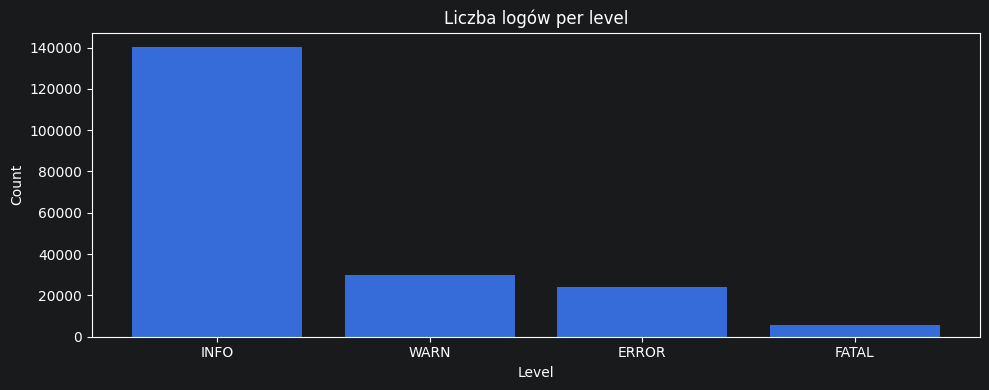

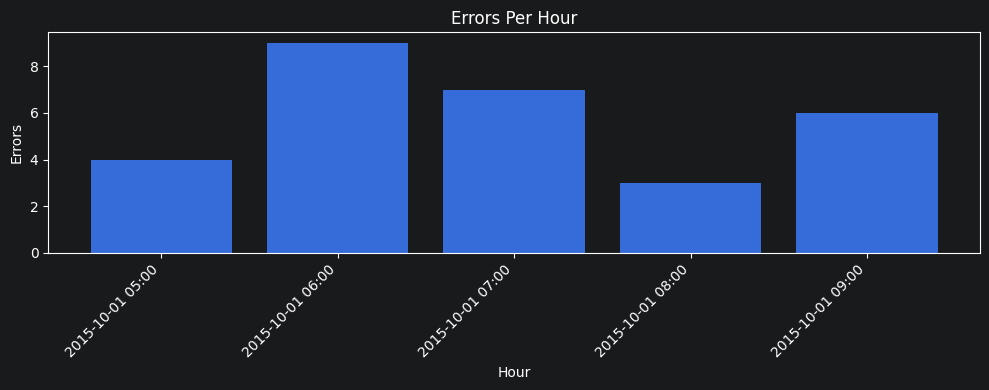

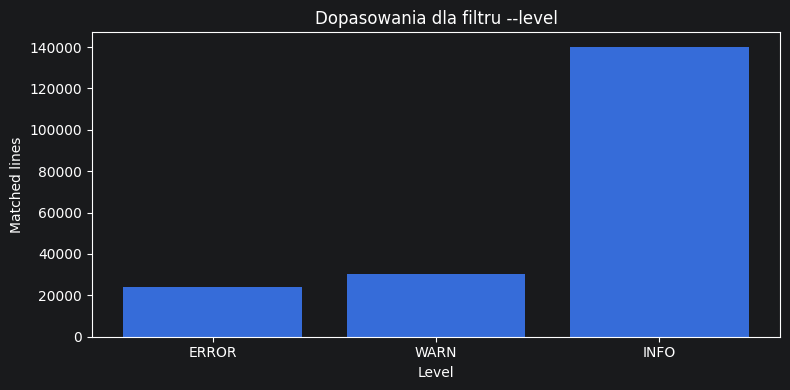

{'ERROR': 23910, 'WARN': 30092, 'INFO': 140105}

In [17]:
# Viz 1: poziomy logów
plot_level_counts(result.level_counts)

# Viz 2: błędy per godzina
plot_errors_per_hour(result.errors_per_hour, hour_from="2015-10-01 05:00", hour_to="2015-10-01 09:00")

# Przykład nowego filtrowania po level (jak --level ERROR)
error_only = analyze_log_file(
    INPUT_LOG,
    AnalysisConfig.from_iterables(levels=("ERROR",)),
)
{
    "matched_lines_level_ERROR": len(error_only.filtered_lines),
    "sample": error_only.filtered_lines[:3],
}

# Viz 3: porównanie liczby linii po filtrze --level
level_compare = {
    "ERROR": len(analyze_log_file(INPUT_LOG, AnalysisConfig.from_iterables(levels=("ERROR",))).filtered_lines),
    "WARN": len(analyze_log_file(INPUT_LOG, AnalysisConfig.from_iterables(levels=("WARN",))).filtered_lines),
    "INFO": len(analyze_log_file(INPUT_LOG, AnalysisConfig.from_iterables(levels=("INFO",))).filtered_lines),
}
plot_level_filter_comparison(level_compare)
level_compare


## 8) Eksport wyników (AnalysisResult)


In [18]:
json_path = REPORTS / "notebook_report.json"
csv_path = REPORTS / "notebook_filtered.csv"
save_report_json(result, str(json_path))
save_filtered_lines_csv(result, str(csv_path))
json_path, csv_path


(WindowsPath('reports/notebook_report.json'),
 WindowsPath('reports/notebook_filtered.csv'))

## 9) OpenMP (main.py --parallel-mode openmp) + wykresy


In [19]:
cmd = [
    sys.executable,
    'main.py',
    '--input', INPUT_LOG,
    '--parallel-mode', 'openmp',
    '--openmp-workers', '4',
]
completed = subprocess.run(cmd, capture_output=True, text=True)
print(completed.stdout)
if completed.returncode != 0:
    print(completed.stderr)
    raise RuntimeError('OpenMP mode failed')



=== SUMMARY ===
Total lines: 200000
Parsed lines: 200000
Parse errors: 0

=== PHRASE COUNTS ===

=== LEVEL COUNTS (ALL DETECTED) ===
ERROR: 23910
FATAL: 5893
INFO: 140105
WARN: 30092

=== ERRORS PER HOUR ===
2015-10-01 00:00 -> 7
2015-10-01 01:00 -> 7
2015-10-01 02:00 -> 5
2015-10-01 03:00 -> 8
2015-10-01 04:00 -> 10
2015-10-01 05:00 -> 4
2015-10-01 06:00 -> 9
2015-10-01 07:00 -> 7
2015-10-01 08:00 -> 3
2015-10-01 09:00 -> 6
2015-10-01 10:00 -> 8
2015-10-01 11:00 -> 7
2015-10-01 12:00 -> 10
2015-10-01 13:00 -> 9
2015-10-01 14:00 -> 6
2015-10-01 15:00 -> 11
2015-10-01 16:00 -> 9
2015-10-01 17:00 -> 5
2015-10-01 18:00 -> 10
2015-10-01 19:00 -> 11
2015-10-01 20:00 -> 8
2015-10-01 21:00 -> 10
2015-10-01 22:00 -> 7
2015-10-01 23:00 -> 7
2015-10-02 00:00 -> 5
2015-10-02 01:00 -> 11
2015-10-02 02:00 -> 5
2015-10-02 03:00 -> 7
2015-10-02 04:00 -> 8
2015-10-02 05:00 -> 5
2015-10-02 06:00 -> 8
2015-10-02 07:00 -> 4
2015-10-02 08:00 -> 12
2015-10-02 09:00 -> 4
2015-10-02 10:00 -> 5
2015-10-02 11

In [20]:
import csv
openmp_rows = []
with open(REPORTS / "benchmark_openmp.csv", "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for i, row in enumerate(reader):
        if i >= 10:
            break
        openmp_rows.append(row)
openmp_rows


[{'threads': '1',
  'time': '0.006418099999791593',
  'speedup': '1.0',
  'efficiency': '1.0'},
 {'threads': '2',
  'time': '0.006189800000356627',
  'speedup': '1.0368832594626343',
  'efficiency': '0.5184416297313171'},
 {'threads': '4',
  'time': '0.006650499999523163',
  'speedup': '0.9650552590409394',
  'efficiency': '0.24126381476023484'},
 {'threads': '8',
  'time': '0.006966200000533718',
  'speedup': '0.9213200883264719',
  'efficiency': '0.11516501104080899'}]

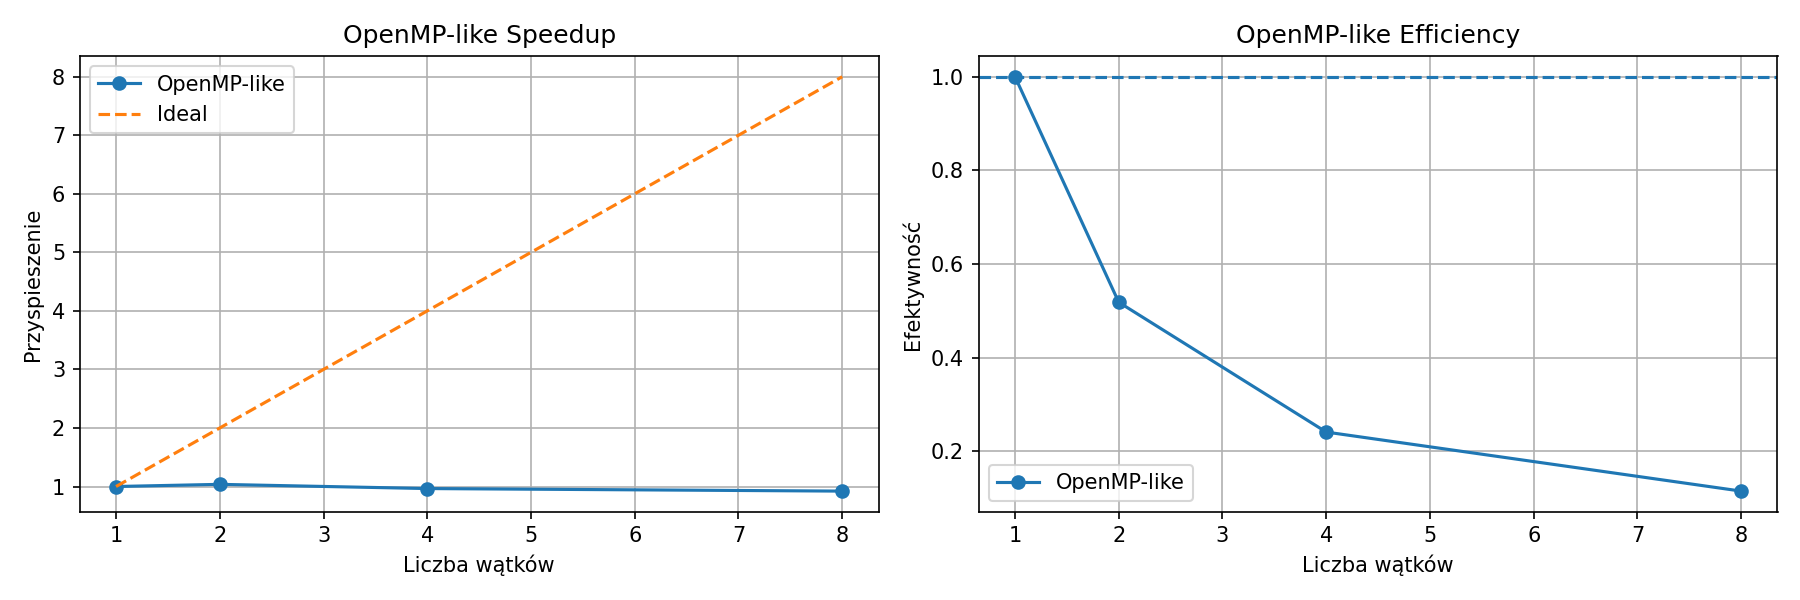

In [21]:
display(Image(filename=str(PLOTS / 'openmp_speedup_efficiency.png')))


## 10) MPI (main.py --parallel-mode mpi) + wykresy


In [22]:
cmd = [
    'mpiexec', '-n', '4',
    sys.executable,
    'main.py',
    '--input', INPUT_LOG,
    '--parallel-mode', 'mpi',
]
completed = subprocess.run(cmd, capture_output=True, text=True)
print(completed.stdout)
if completed.returncode != 0:
    print(completed.stderr)
    raise RuntimeError('MPI mode failed (sprawdź instalację mpiexec / MPI i mpi4py).')



=== SUMMARY ===
Total lines: 200000
Parsed lines: 200000
Parse errors: 0

=== PHRASE COUNTS ===

=== LEVEL COUNTS (ALL DETECTED) ===
ERROR: 23910
FATAL: 5893
INFO: 140105
WARN: 30092

=== ERRORS PER HOUR ===
2015-10-01 00:00 -> 7
2015-10-01 01:00 -> 7
2015-10-01 02:00 -> 5
2015-10-01 03:00 -> 8
2015-10-01 04:00 -> 10
2015-10-01 05:00 -> 4
2015-10-01 06:00 -> 9
2015-10-01 07:00 -> 7
2015-10-01 08:00 -> 3
2015-10-01 09:00 -> 6
2015-10-01 10:00 -> 8
2015-10-01 11:00 -> 7
2015-10-01 12:00 -> 10
2015-10-01 13:00 -> 9
2015-10-01 14:00 -> 6
2015-10-01 15:00 -> 11
2015-10-01 16:00 -> 9
2015-10-01 17:00 -> 5
2015-10-01 18:00 -> 10
2015-10-01 19:00 -> 11
2015-10-01 20:00 -> 8
2015-10-01 21:00 -> 10
2015-10-01 22:00 -> 7
2015-10-01 23:00 -> 7
2015-10-02 00:00 -> 5
2015-10-02 01:00 -> 11
2015-10-02 02:00 -> 5
2015-10-02 03:00 -> 7
2015-10-02 04:00 -> 8
2015-10-02 05:00 -> 5
2015-10-02 06:00 -> 8
2015-10-02 07:00 -> 4
2015-10-02 08:00 -> 12
2015-10-02 09:00 -> 4
2015-10-02 10:00 -> 5
2015-10-02 11

In [23]:
import csv
mpi_rows = []
with open(REPORTS / "benchmark_mpi.csv", "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for i, row in enumerate(reader):
        if i >= 10:
            break
        mpi_rows.append(row)
mpi_rows


[{'processes': '1',
  'time': '0.015754800000649993',
  'speedup': '1.0',
  'efficiency': '1.0'},
 {'processes': '2',
  'time': '0.015182600000116508',
  'speedup': '1.0376878795811715',
  'efficiency': '0.5188439397905857'},
 {'processes': '4',
  'time': '0.020554900000206544',
  'speedup': '0.7664741740651466',
  'efficiency': '0.19161854351628665'},
 {'processes': '8',
  'time': '0.027149999999892316',
  'speedup': '0.580287292843922',
  'efficiency': '0.07253591160549025'}]

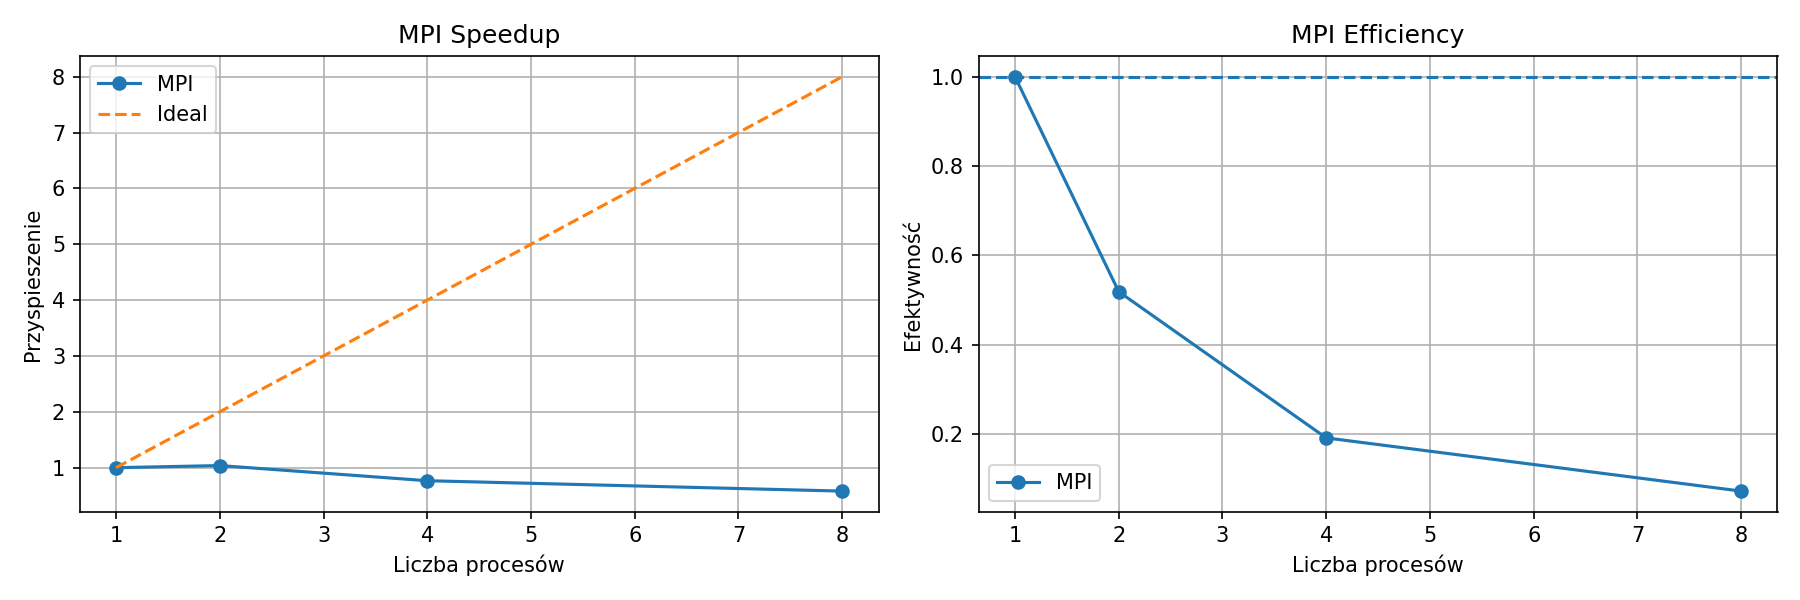

In [24]:
display(Image(filename=str(PLOTS / 'mpi_speedup_efficiency.png')))


## 11) CUDA / GPU (`main.py --parallel-mode cuda`)

CUDA realizuje czesc z polecenia: przyspieszenie zliczania i histogramow na GPU. W implementacji tekst logu jest splaszczany do bufora bajtow, a kernel CUDA liczy poczatki tokenow oraz histogram bajtow. Jezeli CUDA albo `numba.cuda` nie sa dostepne, wynik przechodzi w kontrolowany `cpu-fallback`, co pozwala uruchomic notebook takze na komputerze bez GPU.

In [18]:
cmd = [
    sys.executable,
    "main.py",
    "--input", INPUT_LOG,
    "--parallel-mode", "cuda",
    "--cuda-threads-per-block", "256",
    "--limit", "5",
]
print("$", " ".join(cmd))
completed = subprocess.run(cmd, capture_output=True, text=True)
print(completed.stdout)
if completed.stderr:
    print(completed.stderr)


$ C:\Users\PC\AppData\Local\Programs\Python\Python313\python.exe main.py --input C:\Users\PC\PycharmProjects\prir_projekt\data\raw\Hadoop_200k.log --parallel-mode cuda --cuda-threads-per-block 256 --limit 5

=== SUMMARY ===
Total lines: 200000
Parsed lines: 200000
Parse errors: 0

=== PHRASE COUNTS ===

=== LEVEL COUNTS (ALL DETECTED) ===
ERROR: 23910
FATAL: 5893
INFO: 140105
WARN: 30092

=== ERRORS PER HOUR ===
2015-10-01 00:00 -> 7
2015-10-01 01:00 -> 7
2015-10-01 02:00 -> 5
2015-10-01 03:00 -> 8
2015-10-01 04:00 -> 10

=== FILTERED LINES (first 10) ===
2015-10-01 00:00:21,000 ERROR [main] Speculator: INFO user login successful
2015-10-01 00:02:17,000 INFO [main] JobHistoryUtils: Heartbeat received
2015-10-01 00:02:21,000 INFO [main] JobHistoryUtils: ERROR failed to allocate container
2015-10-01 00:02:49,000 INFO [main] AsyncDispatcher: WARNING memory usage high
2015-10-01 00:03:25,000 INFO [main] AsyncDispatcher: FATAL application crashed
Matched lines: 200000

=== CUDA TOKENIZATION

In [ ]:
with open(INPUT_LOG, "r", encoding="utf-8") as handle:
    cuda_lines = handle.readlines()

cuda_result = benchmark_cuda(cuda_lines, threads_per_block=256)
cuda_result


## 12) Wyniki wymagane do raportu

Ta sekcja generuje artefakty wskazane w tresci zadania: top-N slow, przepustowosc GB/s, porownanie CPU/GPU oraz krotki wniosek o waskim gardle I/O.

In [ ]:
cmd = [
    sys.executable,
    "benchmark_report.py",
    "--input", INPUT_LOG,
    "--openmp-workers", "4",
    "--cuda-threads-per-block", "256",
    "--top-n", "20",
    "--save-dir", str(REPORTS),
]
print("$", " ".join(cmd))
completed = subprocess.run(cmd, capture_output=True, text=True)
print(completed.stdout)
if completed.stderr:
    print(completed.stderr)


In [ ]:
cpu_gpu_csv = REPORTS / "benchmark_cpu_gpu.csv"
top_words_csv = REPORTS / "top_words.csv"

cpu_gpu_df = pd.read_csv(cpu_gpu_csv)
top_words_df = pd.read_csv(top_words_csv)

display(cpu_gpu_df)
display(top_words_df.head(20))


In [ ]:
cpu_gpu_plot = PLOTS / "cpu_gpu_throughput.png"
top_words_plot = PLOTS / "top_words.png"

if cpu_gpu_plot.exists():
    display(Image(filename=str(cpu_gpu_plot)))
else:
    print("Brak wykresu CPU/GPU - prawdopodobnie matplotlib nie jest zainstalowany w tym kernelu.")

if top_words_plot.exists():
    display(Image(filename=str(top_words_plot)))
else:
    print("Brak wykresu top-N - prawdopodobnie matplotlib nie jest zainstalowany w tym kernelu.")


In [ ]:
report_md = REPORTS / "benchmark_report.md"
if report_md.exists():
    display(Markdown(report_md.read_text(encoding="utf-8")))
else:
    print("Raport markdown nie zostal jeszcze wygenerowany.")


## 13) Por?wnanie wydajno?ci: CPU/OpenMP-like, MPI i GPU/CUDA
Poni?ej zostaje klasyczne por?wnanie OpenMP-like i MPI, a por?wnanie CPU/GPU oraz przepustowo?? GB/s s? generowane w sekcji 12.


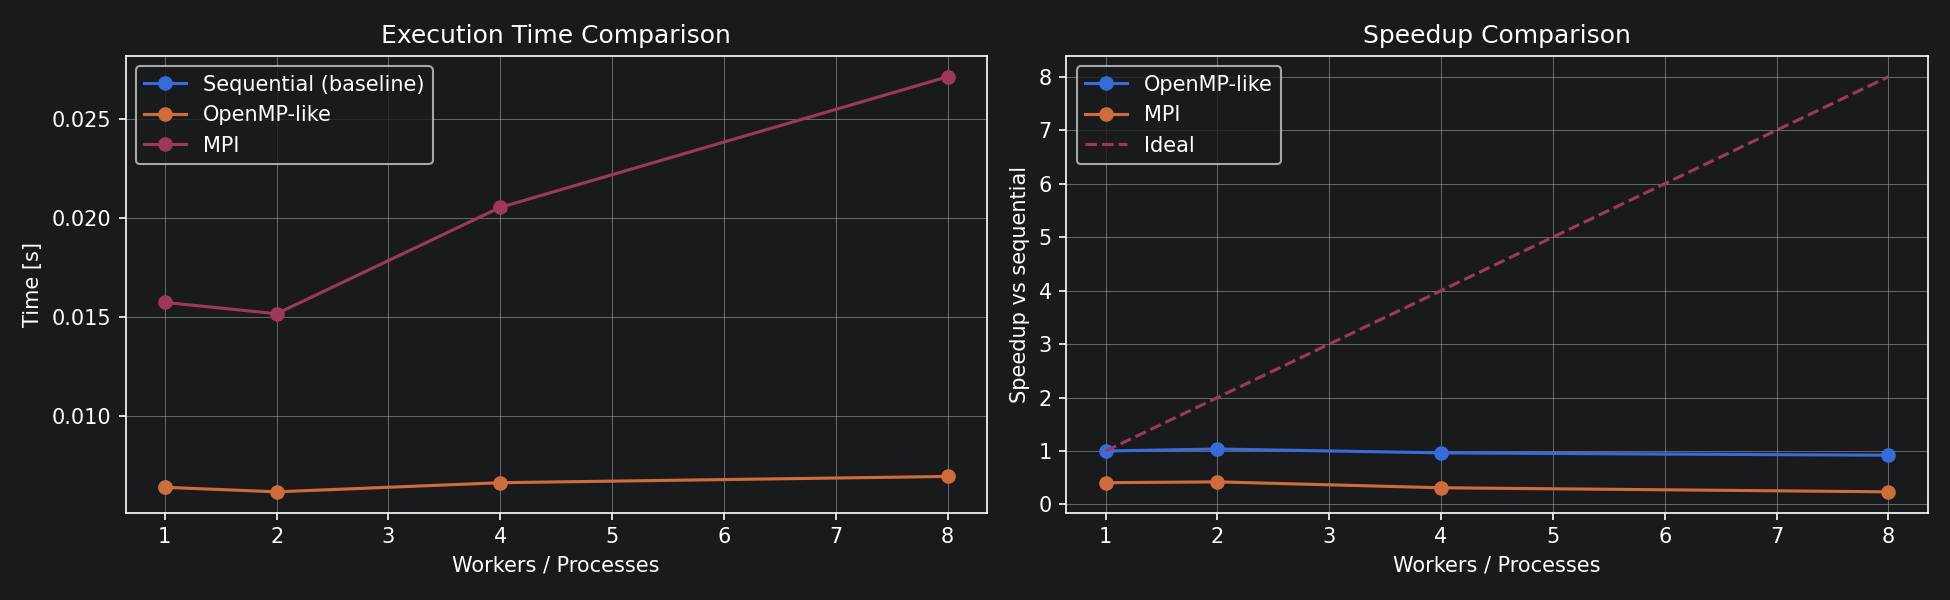

{'sequential_time_s': 0.006418,
 'best_openmp_time_s': 0.00619,
 'best_mpi_time_s': 0.015183}

In [25]:
import csv

openmp_path = REPORTS / "benchmark_openmp.csv"
mpi_path = REPORTS / "benchmark_mpi.csv"

openmp_rows = []
with open(openmp_path, "r", encoding="utf-8") as f:
    for row in csv.DictReader(f):
        openmp_rows.append({"units": int(row["threads"]), "time": float(row["time"])})

mpi_rows = []
with open(mpi_path, "r", encoding="utf-8") as f:
    for row in csv.DictReader(f):
        mpi_rows.append({"units": int(row["processes"]), "time": float(row["time"])})

comparison_plot = PLOTS / "parallel_comparison.png"
summary = plot_parallel_comparison(openmp_rows, mpi_rows, save_path=str(comparison_plot))
display(Image(filename=str(comparison_plot)))
summary
